# Task 3 – Regression: Predict ADR / Revenue

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df= pd.read_csv("hotel_bookings_cleaned.csv")

print(df.shape)
df.head()

(119390, 36)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_guests,total_nights,total_revenue,season,weekend_ratio,lead_time_category
0,1,0,2.227051,2015,5,27,1,-0.92889,-1.310240,0.247897,...,2,-2.015038,0,-0.720694,0.043967,-1.340370,-1.065314,2,-0.993748,0
1,1,0,5.923385,2015,5,27,1,-0.92889,-1.310240,0.247897,...,2,-2.015038,0,-0.720694,0.043967,-1.340370,-1.065314,2,-0.993748,0
2,1,0,-0.907814,2015,5,27,1,-0.92889,-0.786207,-1.478447,...,2,-0.530935,0,-0.720694,-1.340324,-0.949352,-0.842039,2,-0.993748,2
3,1,0,-0.851667,2015,5,27,1,-0.92889,-0.786207,-1.478447,...,2,-0.530935,0,-0.720694,-1.340324,-0.949352,-0.842039,2,-0.993748,2
4,1,0,-0.842309,2015,5,27,1,-0.92889,-0.262174,0.247897,...,2,-0.075810,0,0.540666,0.043967,-0.558334,-0.481822,2,-0.993748,2


## 1. Business Understanding

The objective of this regression task is to predict the Average Daily Rate (ADR) or the total revenue for hotel bookings. This helps hotel management forecast revenue, import pricing strategies, and make better operational decisions.

The target variable selected for this regression task istotal_revenue, which was calculated as adr * total_nights. This allows the model to predict the estimated booking revenue based on booking and customer-related features.

In this task, total_revenue represents potential booking revenue. For cancelled bookings, this may not represent actual earned revenue, so this is a limitation of the model.

In [3]:
X = df.drop(["total_revenue", "adr"], axis=1)
y = df["total_revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (95512, 34)
Testing Set: (23878, 34)


## 2. Model 1 - Linear regression

### Linear Regression

Linear Regression was used as a baseline regression model to predict hotel revenue. The model provides a simple relationship between the predictor variables and the target variable (total_revenue).

In [4]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R² Score:", r2_score(y_test, y_pred_lr))

MAE: 0.33962513460170035
RMSE: 0.5671530451468014
R² Score: 0.6791355228380854


## 3. Model 2 - Random Forest Regressor

### Hyperparameters

- n_estimators = 100
- random_state = 42

The Random Forest Regressor uses 100 decision trees to reduce variance and improve prediction accuracy. The random_state parameter ensures reproducible results.

In [5]:
rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42
    )

rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R² Score:", r2_score(y_test, y_pred_rf))

MAE: 0.09800441206395269
RMSE: 0.25627293798175377
R² Score: 0.9344871341134916


## 4. Model3 - Gradient Boosting Regressor

### Hyperparameters

- random_state = 42

Gradient Boosting Regressor builds trees sequentially, where each tree attempts to correct the errors made by previous trees. The random_state parameter ensures reproducible results.

In [6]:
gb_model= GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("R² Score:", r2_score(y_test, y_pred_gb))

MAE: 0.20491845715885337
RMSE: 0.352334453348919
R² Score: 0.8761684443227664


In [7]:
comparison_reg = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regressor",
        "Gradient Boosting Regressor"
    ],
    "MAE": [
        0.3396,
        0.0980,
        0.2049
    ],
    "RMSE": [
        0.5672,
        0.2563,
        0.3523
    ],
    "R² Score": [
        0.6791,
        0.9345,
        0.8762
    ]
})

comparison_reg

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.3396,0.5672,0.6791
1,Random Forest Regressor,0.0980,0.2563,0.9345
2,Gradient Boosting Regressor,0.2049,0.3523,0.8762


Since total_revenue was scaled during preprocessing, the MAE and RMSE values are interpreted in standardized units rather than original currency values. Therefore, R² is especially useful for comparing model performance because it shows how well the model explains variation in revenue.

## Best Model Explanation

The Random Forest Regressor performed best overall because it achieved the lowest MAE and RMSE and the highest R² score. This means it predicted total revenue more accurately than the other regression models. Random Forest can capture non-linear relationships in the hotel booking data, which makes it suitable for revenue prediction.

## 5. Evaluation and Reporting

## Model Comparison

### Model Evaluation

Three regression algorithms were evaluated to predict total revenue.

Linear Regression achieved an R² score of 0.6791, indicating moderate predictive performance.

Gradient Boosting Regressor improved the results with an R² score of 0.8762 and lower prediction errors.

Random Forest Regressor achieved the best overall performance, producing the lowest MAE and RMSE values and the highest R² score of 0.9345.

Based on these evaluation results, Random Forest Regressor was selected as the best-performing regression model.

## Hyperparameter Explanations

The adr column was removed from the input features because total_revenue was calculated using adr and total_nights. Removing adr helped prevent the model from predicting revenue too easily using a directly related feature.

### Linear Regression
- Default parameters were used as a baseline model.

### Random Forest Regressor
- n_estimators = 100
- Uses 100 trees to improve prediction performance.
- random_state = 42
- Ensures reproducibility.

### Gradient Boosting Regressor
- random_state = 42
- Ensures consistent results during training.

In [8]:
import matplotlib.pyplot as plt

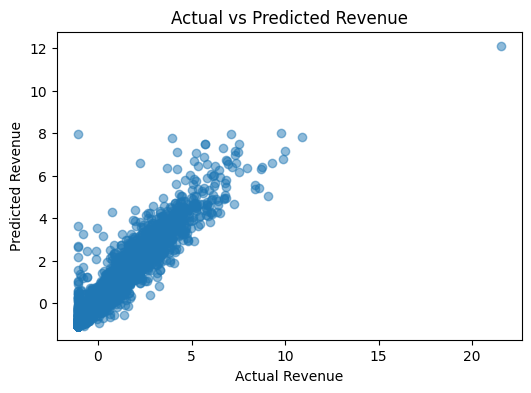

In [9]:
plt.figure(figsize=(6,4))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")
plt.show()

### Interpretation

The Actual vs Predicted Revenue plot shows a clear positive relationship between actual revenue and the values predicted by the Random Forest Regressor. Most points are close to the expected trend, showing that the model can predict revenue well. This is supported by the Random Forest Regressor achieving the highest R² score of 0.9345 and the lowest MAE and RMSE values among the tested models.

### Business Recommendation

The Random Forest Regressor can be used to forecast future booking revenue with high accuracy.

Hotel management can use these predictions to:

- improve pricing strategies
- optimize room allocation
- forecast revenue trends
- support budgeting and operational planning

Accurate revenue forecasting can help improve financial decision-making and resource management.